# Latents over the entire experiment, and region contributions to each latent — kcEXP00H

**Todolist point 2:** *plot latents over entire experiment, then compute region contributions to each latent.*

This notebook does two things with the existing multisession LFADS fit (5 flies × 18 trials × 50 factors,
whole-trial 1050-frame model):

1. **Latent timeline** — plot the inferred latents *continuously across the whole session* (all 18 trials
   concatenated in acquisition order), overlaid with trial boundaries, the 8-way stimulus condition, and the
   odor / walk / vision ON windows. Unlike the condition-averaged views in notebooks 3 & 5, this shows
   session-scale structure (drift / arousal) and how each latent locks to the stimuli trial by trial.
2. **Region contributions to each latent** — map each plotted latent back to the brain regions it drives,
   through the (OLS-recovered) linear readout, averaged across flies.

> Latents are plotted as the **pooled orthogonal factor modes** (the decorrelated eigen-modes of the factor
> covariance), because raw factor indices are rotation-ambiguous. Mode 0 is the dominant, largely global
> stimulus-locked mode. For the full per-factor region-contribution suite see `5_region_contributions_kcEXP00H_atle.ipynb`.

## Parameters

In [1]:
import re, sys
from glob import glob
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib import cm

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# --- utils.Xarray_UtilFns lives at the repo root; this notebook runs from
#     lfads_on_kcEXP00H/, so add '..' to the path. ---
sys.path.insert(0, '..')

# --- Source xarray (.nc) files holding the stimulus regressors + region names. ---
# NOTE: the old absolute mount ('/media/server/gklab/.../xarray_files/') is stale;
# the .nc files are local in the repo, so use the repo-relative path.
XARRAY_DIR = '../datasets/xarray_files/'

# --- Directory containing lfads_output_*.h5 (from run_posterior_sampling). ---
# Auto-pick the most recent run's best_model (same run the other notebooks used).
H5_DIR = None
if H5_DIR is None:
    cands = sorted(Path('../runs').glob(
        'kcEXP00H_multisession_202606291751/pbt/*/*/best_model'))
    cands = [c for c in cands if list(c.glob('lfads_output_*.h5'))]
    assert cands, 'No best_model with lfads_output_*.h5 found under ../runs'
    H5_DIR = cands[-1]
print('Using LFADS outputs from:', H5_DIR)
H5_DIR = Path(H5_DIR)

# 8-way stimulus condition order (V=vision, O=odor, F=forward-walk; x=off)
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

# Stimulus channels: name -> (per-timepoint state coord, per-trial presence coord)
MODALITIES = {'odor':   ('odor_state_frame', 'odor_trial_bool'),
              'walk':   ('fw_state_frame',   'fw_trial_bool'),
              'vision': ('vis_state_frame',  'vis_trial_bool')}

# Optic-lobe neuropils flagged as likely visual/imaging artifacts -> excluded from
# region RANKINGS (not from the model). Same convention as notebook 5.
ARTIFACT_BASES = ['MED', 'AME', 'LO', 'LOP']

Using LFADS outputs from: ../runs/kcEXP00H_multisession_202606291751/pbt/kcEXP00H_multisession_zscored/260629/best_model


## Load LFADS factors (original trial order)

In [2]:
def merge_train_valid(tr, va, ti, vi):
    '''Restore original (acquisition) trial order 0..N-1 from the train/valid split.'''
    out = np.full((len(tr) + len(va), *tr.shape[1:]), np.nan, dtype=tr.dtype)
    out[ti] = tr; out[vi] = va
    return out

h5_paths = sorted(glob(str(H5_DIR / 'lfads_output_*.h5')))
assert h5_paths, f'No lfads_output_*.h5 in {H5_DIR}'
print(f'Found {len(h5_paths)} HDF5 files')

fly_data = {}          # fly_stem -> dict(factors, output_params, readin, readout_bias)
fly_stems = []
SHORT = {}             # fly_stem -> 'H30003-005'
for path in h5_paths:
    stem = Path(path).stem.replace('lfads_output_', '')
    fly_stems.append(stem)
    with h5py.File(path) as f:
        ti = f['train_inds'][()].astype(int); vi = f['valid_inds'][()].astype(int)
        factors = merge_train_valid(f['train_factors'][()], f['valid_factors'][()], ti, vi)
        outp = merge_train_valid(f['train_output_params'][()],
                                 f['valid_output_params'][()], ti, vi)
        readin = f['readin_weight'][()]
        rbias = f['readout_bias'][()]
    fly_data[stem] = dict(factors=factors, output_params=outp,
                          readin=readin, readout_bias=rbias)
    m = re.search(r'H\d+-\d+', stem); SHORT[stem] = m.group() if m else stem
    print(f'  {SHORT[stem]}: factors {factors.shape}, output_params {outp.shape}')

n_fac = fly_data[fly_stems[0]]['factors'].shape[-1]
n_time = fly_data[fly_stems[0]]['factors'].shape[1]
n_flies = len(fly_stems)
print(f'n_factors = {n_fac}, n_time = {n_time}, n_flies = {n_flies}')

Found 5 HDF5 files
  H30003-005: factors (18, 1050, 50), output_params (18, 1050, 69)
  H34006-007: factors (18, 1050, 50), output_params (18, 1050, 71)
  H35005-006: factors (18, 1050, 50), output_params (18, 1050, 71)
  H36006-007: factors (18, 1050, 50), output_params (18, 1050, 71)
  H37003-004: factors (18, 1050, 50), output_params (18, 1050, 69)
n_factors = 50, n_time = 1050, n_flies = 5


## Region names, per-fly region masks, and stimulus regressors from the xarray

In [3]:
from utils.Xarray_UtilFns import load_group_xarrays

ds_list = load_group_xarrays(XARRAY_DIR)
ds_by_flyid = {ds.attrs['fly_id']: ds for ds in ds_list}

# Canonical 75-region order (shared across all flies)
REGION_NAMES = list(ds_list[0].coords['region'].values)
N_REGIONS = len(REGION_NAMES)

# Flagged artifact regions on the canonical frame (base name in ARTIFACT_BASES, both hemispheres)
ARTIFACT_REGIONS = [rn for rn in REGION_NAMES if rn.rsplit('-', 1)[0] in ARTIFACT_BASES]
ARTIFACT_MASK = np.array([rn in ARTIFACT_REGIONS for rn in REGION_NAMES])

# Each fly's LFADS h5 was trained only on its non-dead regions (data prep drops all-NaN
# regions), so per-fly counts are 69-71, NOT 75. Recompute that keep-mask to map each fly's
# h5 regions back onto the canonical 75-region names.
keep_mask_by_flyid = {}
for ds in ds_list:
    arr = ds['deltaF_rg'].values
    keep_mask_by_flyid[ds.attrs['fly_id']] = ~np.isnan(arr).all(axis=(0, 1))

def find_flyid(stem):
    matches = [fid for fid in keep_mask_by_flyid if fid in stem]
    assert len(matches) == 1, (stem, matches)
    return matches[0]

# Per-fly indices into the canonical 75, plus condition / baseline / stimulus regressors
canon_idx = {}         # fly_stem -> (n_reg_fly,) indices into canonical 75
cond = {}              # fly_stem -> (n_trials,) condition strings
is_baseline = {}       # fly_stem -> (n_trials,) bool
state_frame = {}       # fly_stem -> {modality -> (n_time,) 0/1 within-trial timing}
trial_bool = {}        # fly_stem -> {modality -> (n_trials,) bool}
onset_frame = {}       # fly_stem -> int median odor onset frame
for stem in fly_stems:
    fid = find_flyid(stem); ds = ds_by_flyid[fid]
    canon_idx[stem] = np.where(keep_mask_by_flyid[fid])[0]
    cond[stem] = np.asarray(ds['condition'].values).reshape(-1).astype(str)
    is_baseline[stem] = np.asarray(ds['is_baseline'].values).reshape(-1).astype(bool)
    onset_frame[stem] = int(np.median(ds.attrs['odor_framestarts_within_trial']))
    state_frame[stem] = {m: (np.asarray(ds[sv].values).reshape(-1) > 0).astype(int)
                         for m, (sv, bv) in MODALITIES.items()}
    trial_bool[stem] = {m: np.asarray(ds[bv].values).reshape(-1).astype(bool)
                        for m, (sv, bv) in MODALITIES.items()}
    # alignment: readout region count must match canon_idx length
    assert len(canon_idx[stem]) == fly_data[stem]['output_params'].shape[-1], stem
print(f'{N_REGIONS} canonical regions; artifacts flagged ({len(ARTIFACT_REGIONS)}):',
      ARTIFACT_REGIONS)

  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP  18 trials  conds: ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

Loaded 5 datasets from ../datasets/xarray_files/
75 canonical regions; artifacts flagged (8): ['AME-R', 'LO-R', 'LOP-R', 'MED-R', 'AME-L', 'LO-L', 'LOP-L', 'MED-L']


## Readout recovery + orthogonal latent basis

In [4]:
from numpy.linalg import lstsq, eigh

def recover_readout_weights(factors, output_params):
    '''OLS: output_params ~ factors @ W.T + b. Returns W [n_reg, n_fac], b [n_reg].
    Exact, since the LFADS readout is linear (the matrix itself is not stored in the h5).'''
    nf = factors.shape[-1]; nr = output_params.shape[-1]
    F = factors.reshape(-1, nf); O = output_params.reshape(-1, nr)
    F_aug = np.column_stack([F, np.ones(len(F))])
    coef, *_ = lstsq(F_aug, O, rcond=None)
    return coef[:nf, :].T, coef[nf, :]

def to_canon(arr, stem, fill=np.nan):
    '''Scatter a per-fly (n_reg_fly, ...) array onto the canonical (75, ...) frame.'''
    out = np.full((N_REGIONS,) + arr.shape[1:], fill, dtype=float)
    out[canon_idx[stem]] = arr
    return out

# Native readout matrix per fly (OLS-recovered)
readout_W = {s: recover_readout_weights(fly_data[s]['factors'],
                                        fly_data[s]['output_params'])[0]
             for s in fly_stems}

In [5]:
# ---- Common orthogonal factor-mode basis (pooled across flies) ----
# Raw factor indices are rotation-ambiguous, so we plot the decorrelated eigen-modes of the
# pooled factor covariance instead. This is the same basis as notebook 5's Fig 4.1, and it is
# cross-fly comparable.
allF = np.concatenate([fly_data[s]['factors'].reshape(-1, n_fac) for s in fly_stems], 0)
lamP, VP = eigh(np.cov(allF.T)); o = np.argsort(lamP)[::-1]; lamP = lamP[o]; VP = VP[:, o]

# Sign convention: eigenvector signs are arbitrary (v and -v equivalent). Orient each mode so the
# NON-ARTIFACT region it most strongly drives has a positive readout loading (dominant region up
# <=> mode up), so mode polarity tracks the real dF/F signal.
Lm_anchor = np.nanmean(np.stack([np.stack([to_canon(readout_W[s] @ VP[:, k], s)
                                           for k in range(n_fac)], 1)
                                 for s in fly_stems], 0), 0)          # (75, n_fac)
Lm_anchor[ARTIFACT_MASK] = np.nan
flip = np.ones(n_fac)
for k in range(n_fac):
    col = Lm_anchor[:, k]
    if not np.all(np.isnan(col)):
        flip[k] = np.sign(col[np.nanargmax(np.abs(col))]) or 1.0
VP = VP * flip[np.newaxis, :]

# Project each fly's factors onto the sign-fixed pooled modes -> (trials, time, n_fac)
modes = {s: (fly_data[s]['factors'].reshape(-1, n_fac) @ VP).reshape(-1, n_time, n_fac)
         for s in fly_stems}
print('Top-6 modes, % of pooled factor variance:',
      [f'{lamP[k] / lamP.sum():.0%}' for k in range(6)])

/tmp/ipykernel_2177362/2626366331.py:11: RuntimeWarning: Mean of empty slice
  Lm_anchor = np.nanmean(np.stack([np.stack([to_canon(readout_W[s] @ VP[:, k], s)


Top-6 modes, % of pooled factor variance: ['45%', '17%', '13%', '9%', '7%', '5%']


## Fig 1 — Latents over the entire experiment

Each fly's top modes concatenated across all 18 trials into one continuous session timeline (x-axis = real
acquisition time, since trial index is acquisition order). The top colour strip shows each trial's 8-way
condition (`B` marks the experiment-start baseline trials); shaded bands mark the odor / walk / vision ON
windows within each trial; light vertical lines are trial boundaries.

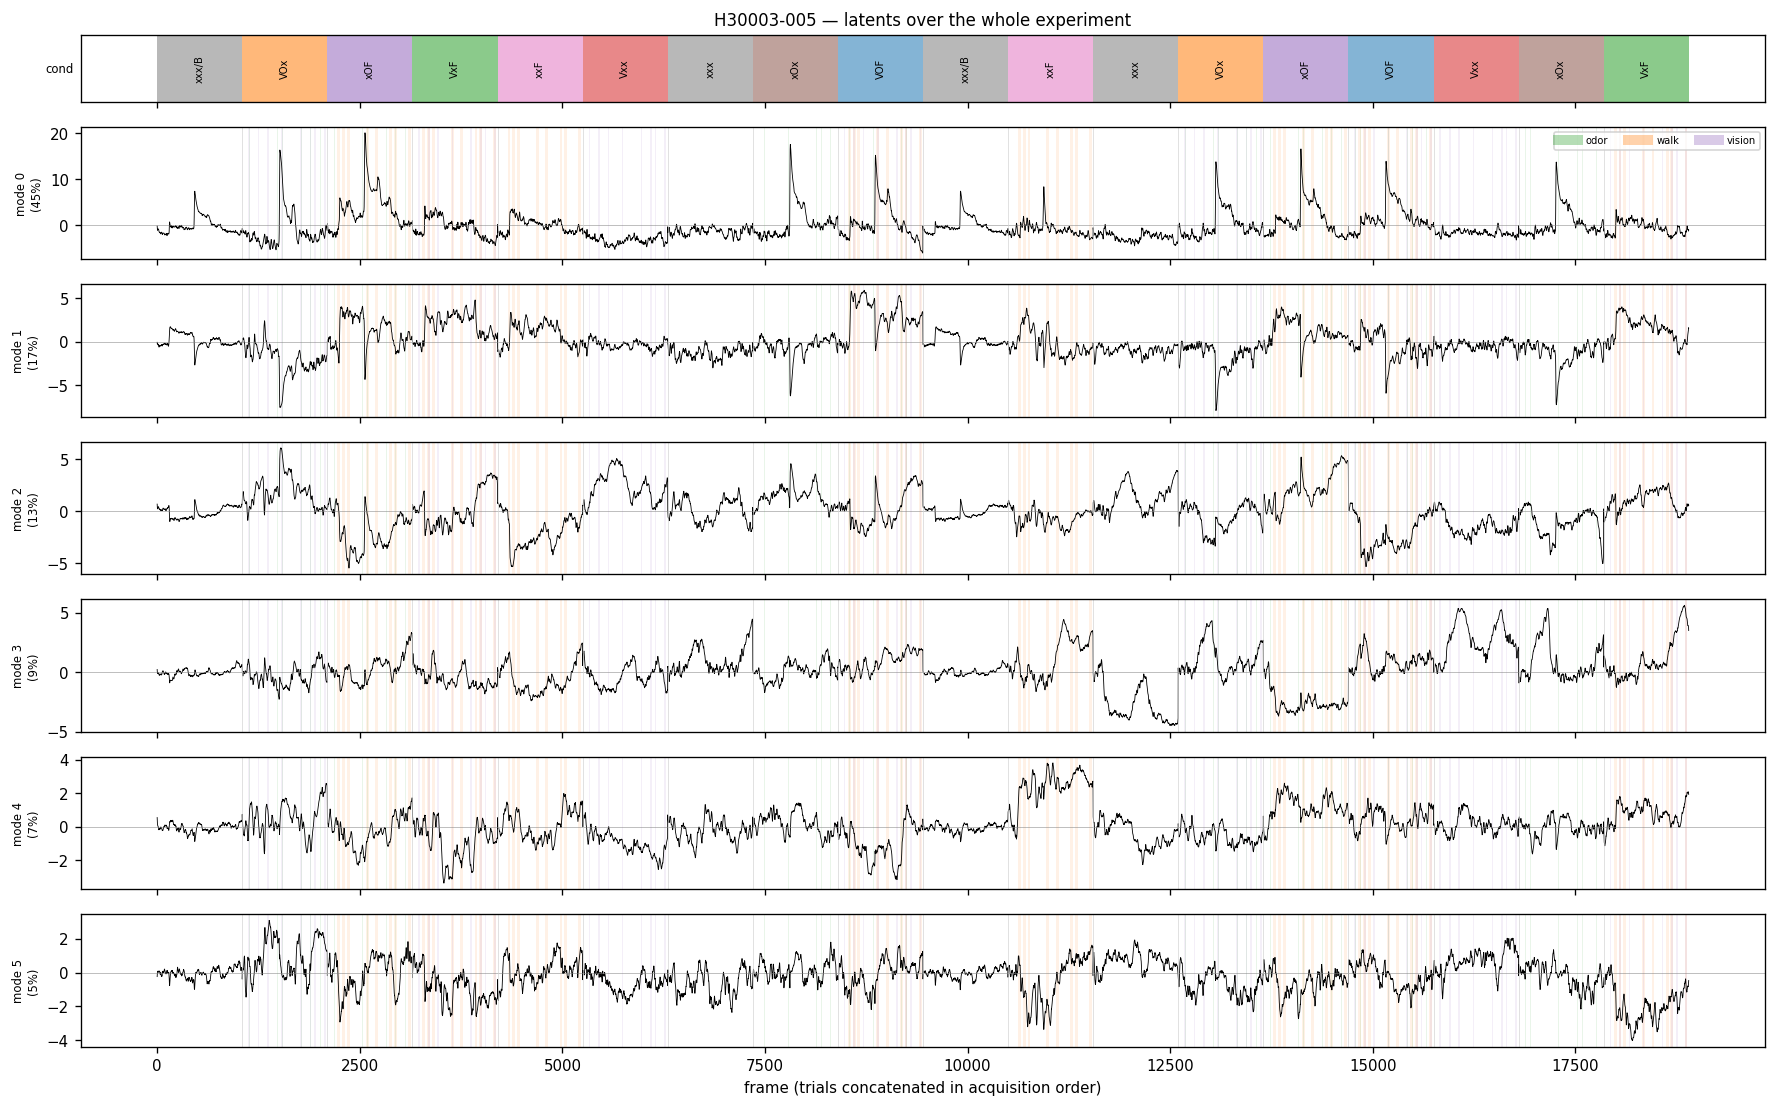

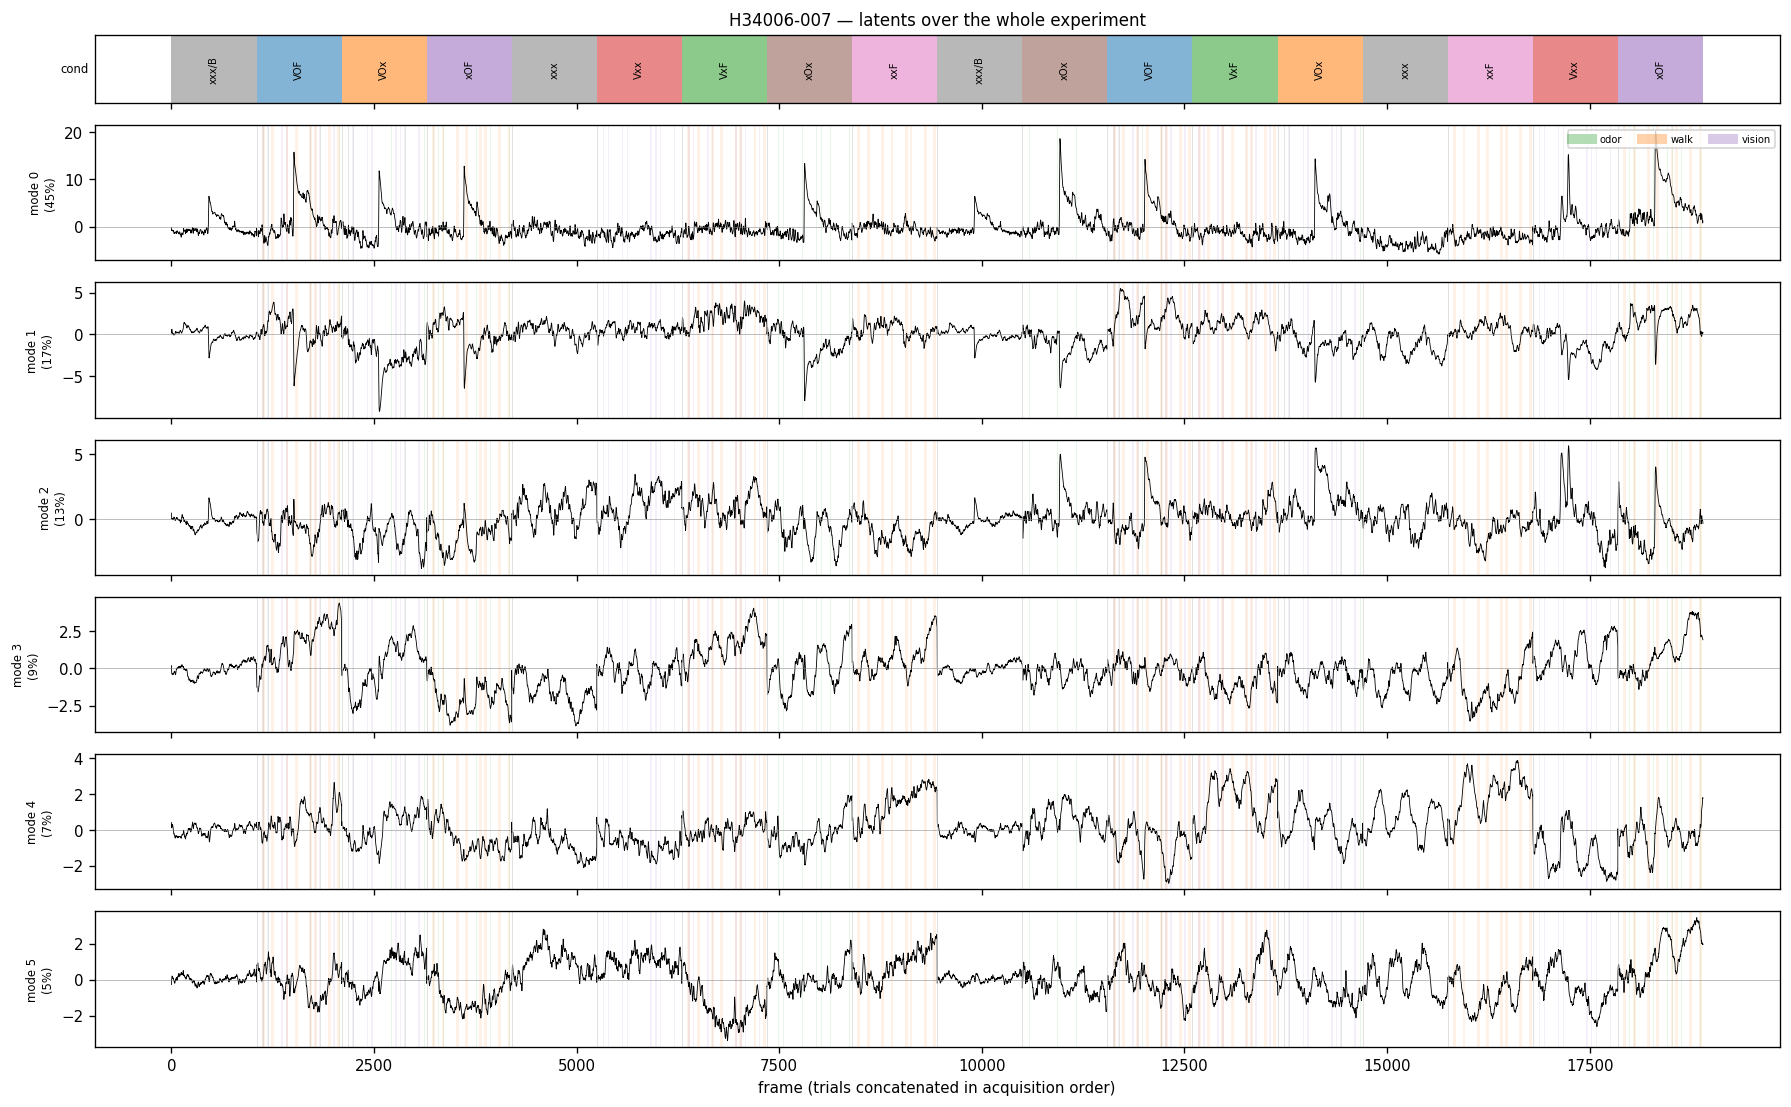

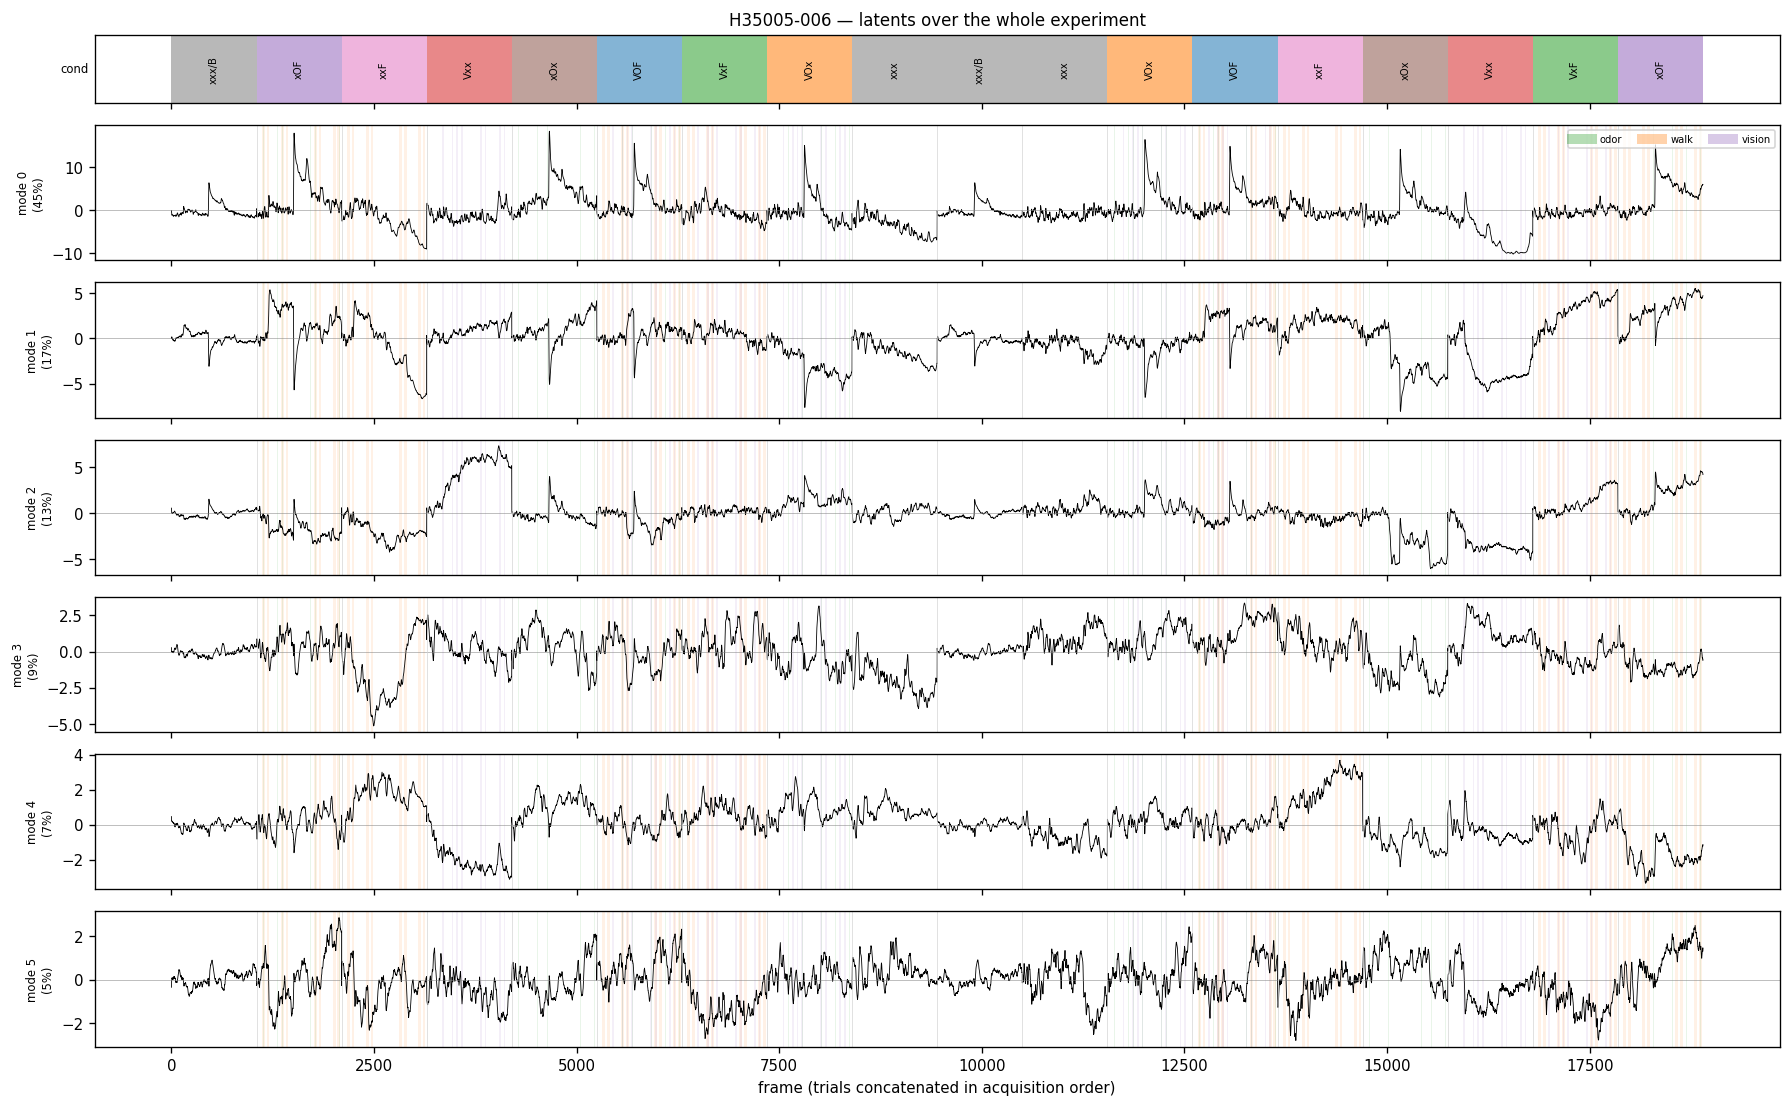

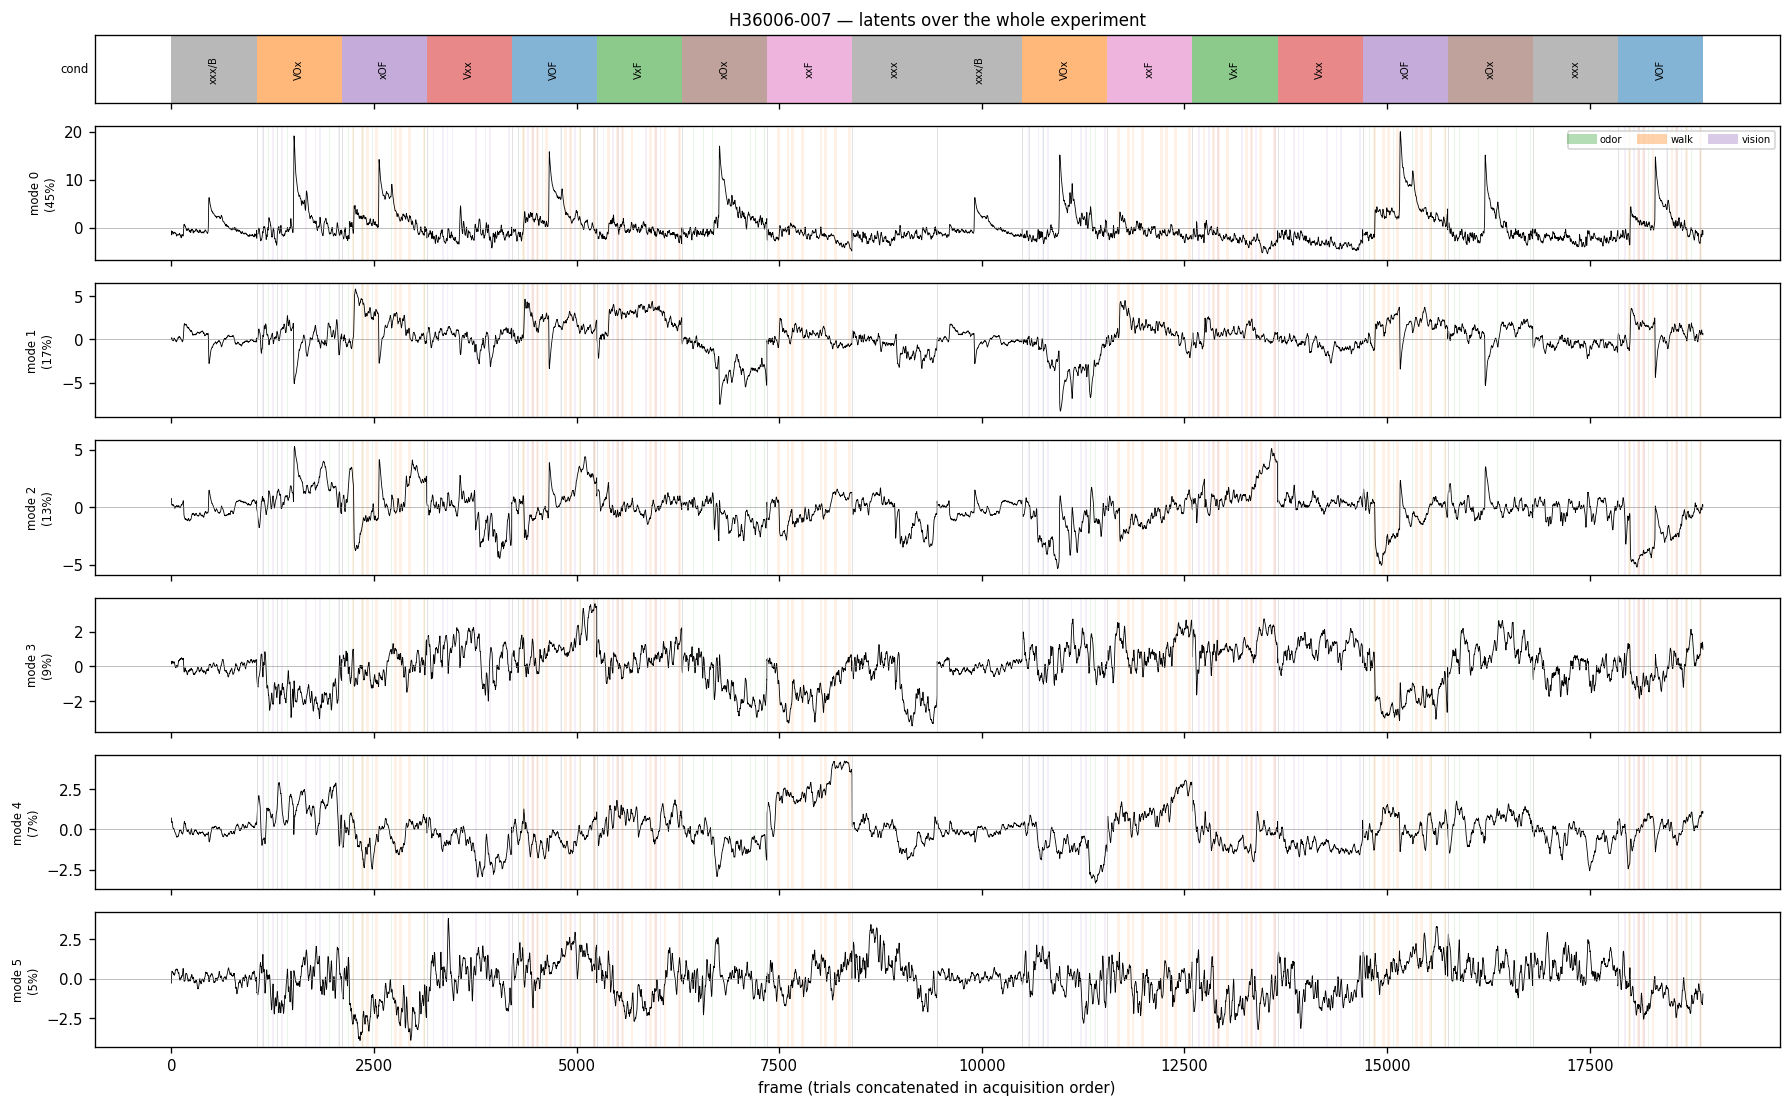

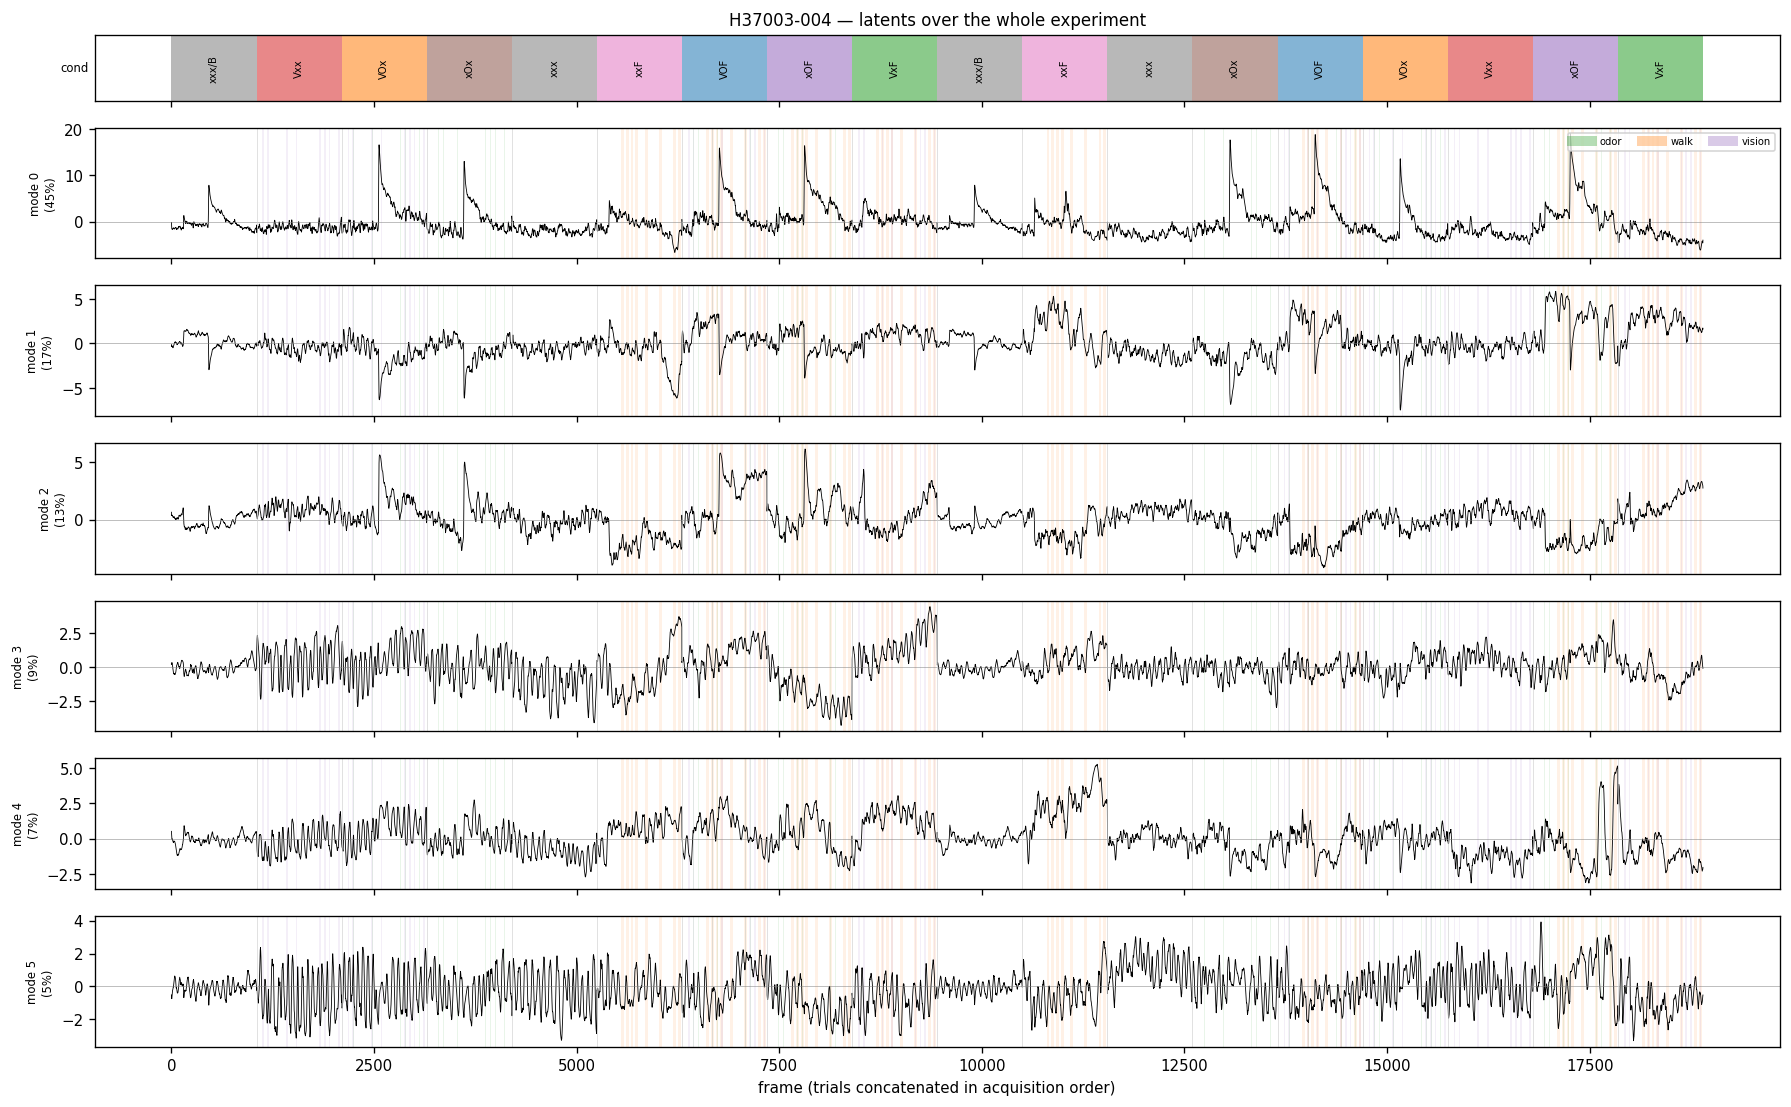

Colour strip = 8-way condition per trial (B = baseline). Bands = odor/walk/vision ON.


In [6]:
K = 6                                   # number of top modes to display
stim_colors = {'odor': 'tab:green', 'walk': 'tab:orange', 'vision': 'tab:purple'}
cond_cmap = {c: cm.tab10(i % 10) for i, c in enumerate(COND_ORDER)}

def stim_mask_continuous(stem, mod):
    '''Boolean (n_trials*n_time,) True where `mod` is ON, over the concatenated session axis.'''
    m = np.zeros(n_time * len(cond[stem]), bool)
    for i in range(len(cond[stem])):
        if trial_bool[stem][mod][i]:
            m[i * n_time:(i + 1) * n_time] = state_frame[stem][mod].astype(bool)
    return m

for stem in fly_stems:
    M = modes[stem]                                     # (n_trials, n_time, n_fac)
    n_tr = M.shape[0]
    cont = M.reshape(n_tr * n_time, n_fac)              # concatenated latent timeline
    x = np.arange(n_tr * n_time)
    smask = {mod: stim_mask_continuous(stem, mod) for mod in MODALITIES}

    fig, axes = plt.subplots(K + 1, 1, figsize=(15, 1.35 * K + 1.2), sharex=True,
                             gridspec_kw={'height_ratios': [0.5] + [1] * K})
    strip = axes[0]
    for i in range(n_tr):
        strip.axvspan(i * n_time, (i + 1) * n_time,
                      color=cond_cmap[cond[stem][i]], alpha=0.55, lw=0)
        lab = cond[stem][i] + ('/B' if is_baseline[stem][i] else '')
        strip.text((i + 0.5) * n_time, 0.5, lab, ha='center', va='center',
                   fontsize=6, rotation=90)
    strip.set_yticks([]); strip.set_ylabel('cond', fontsize=7, rotation=0, ha='right', va='center')
    strip.set_title(f'{SHORT[stem]} — latents over the whole experiment', fontsize=10)

    for k in range(K):
        ax = axes[k + 1]
        ax.plot(x, cont[:, k], lw=0.5, color='k')
        ax.axhline(0, color='grey', lw=0.3)
        for i in range(1, n_tr):
            ax.axvline(i * n_time, color='lightgrey', lw=0.4)
        ylim = ax.get_ylim()
        for mod in MODALITIES:
            ax.fill_between(x, ylim[0], ylim[1], where=smask[mod],
                            color=stim_colors[mod], alpha=0.10, lw=0)
        ax.set_ylim(ylim)
        ax.set_ylabel(f'mode {k}\n({lamP[k] / lamP.sum():.0%})', fontsize=7)
    axes[-1].set_xlabel('frame (trials concatenated in acquisition order)')
    # one shared legend for the stimulus bands
    handles = [plt.Line2D([0], [0], color=stim_colors[m], lw=6, alpha=0.35) for m in MODALITIES]
    axes[1].legend(handles, list(MODALITIES), loc='upper right', fontsize=6, ncol=3)
    plt.tight_layout(); plt.show()

print('Colour strip = 8-way condition per trial (B = baseline). Bands = odor/walk/vision ON.')

## Fig 2 — Region contributions to each latent (mode)

Each plotted latent is a linear combination of regions through the readout. The cross-fly region loading of
mode *k* is `mean_flies to_canon(W_readout @ v_k)`. Left: a region × mode heatmap for the same top modes
plotted above (so the timeline and the anatomy share one basis). Right/printed: the top ± regions per mode.
Optic-lobe artifact regions are shown but excluded from the printed rankings.

/tmp/ipykernel_2177362/3635275166.py:2: RuntimeWarning: Mean of empty slice
  Lmode = np.nanmean(np.stack([np.stack([to_canon(readout_W[s] @ VP[:, k], s)


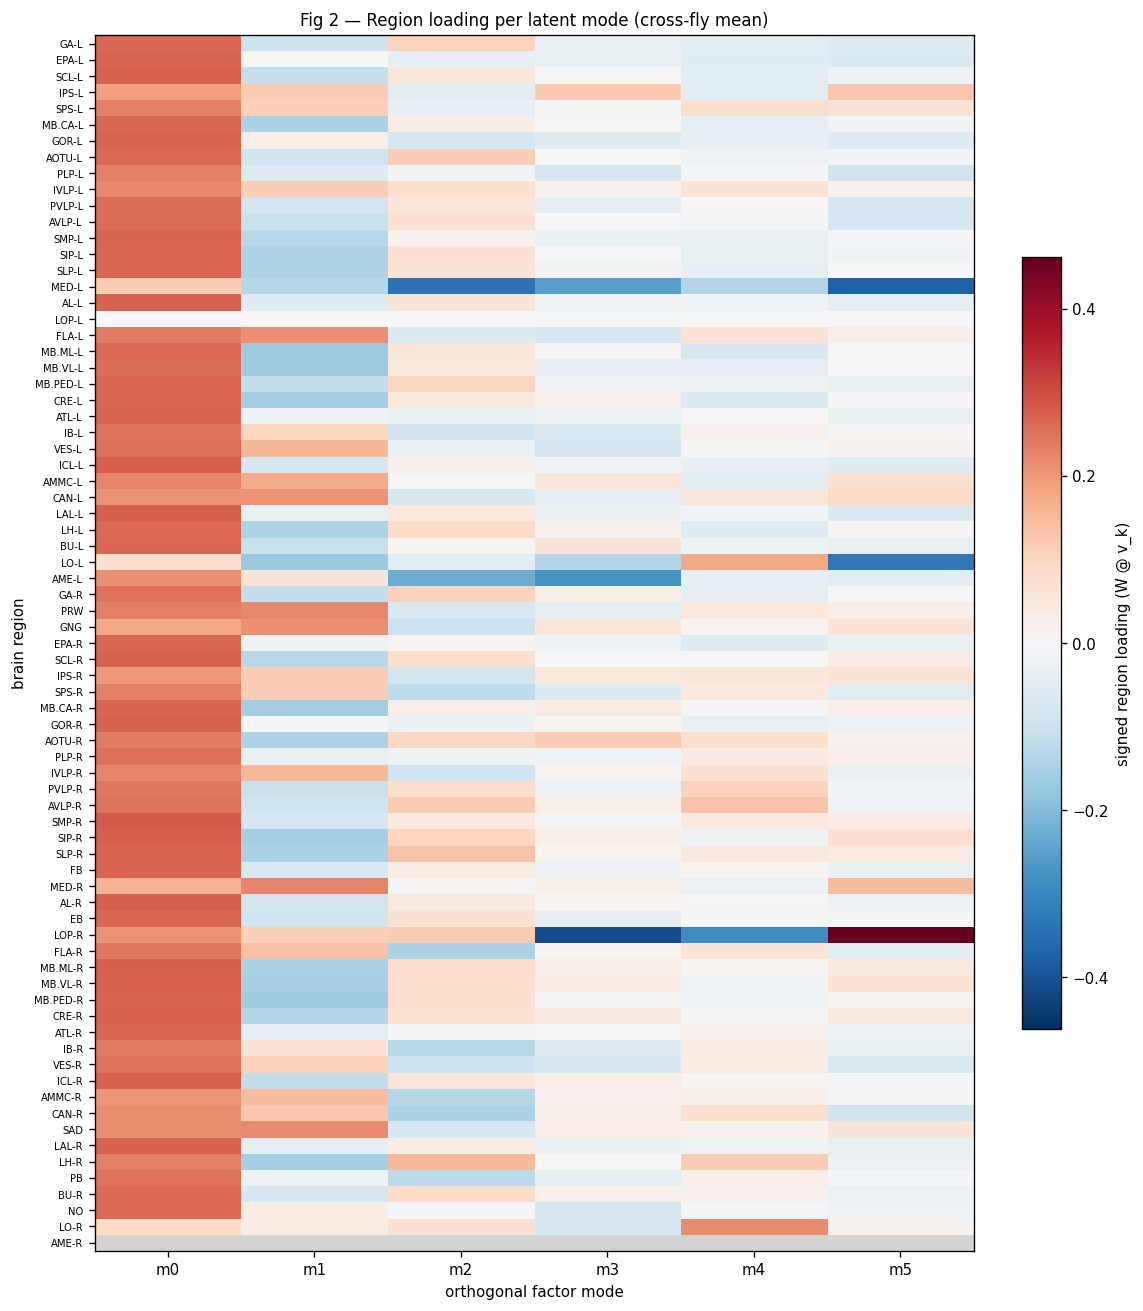

Top +/- non-artifact regions per mode (cross-fly signed loading):
  mode 0 (45% var):  + SMP-R(+0.28), AL-R(+0.28), ICL-L(+0.28), SIP-R(+0.28)   |   - GNG(+0.18), IPS-L(+0.19), IPS-R(+0.20), AMMC-R(+0.20)
  mode 1 (17% var):  + PRW(+0.22), SAD(+0.22), FLA-L(+0.21), GNG(+0.21)   |   - MB.VL-L(-0.17), MB.ML-L(-0.16), MB.PED-R(-0.16), MB.CA-R(-0.16)
  mode 2 (13% var):  + LH-R(+0.15), SLP-R(+0.13), AVLP-R(+0.12), AOTU-L(+0.11)   |   - CAN-R(-0.15), FLA-R(-0.14), AMMC-R(-0.13), IB-R(-0.13)
  mode 3 (9% var):  + IPS-L(+0.12), AOTU-R(+0.11), BU-L(+0.06), GNG(+0.06)   |   - VES-L(-0.09), NO(-0.08), PLP-L(-0.08), FLA-L(-0.08)
  mode 4 (7% var):  + AVLP-R(+0.13), LH-R(+0.12), PVLP-R(+0.11), SPS-L(+0.08)   |   - MB.ML-L(-0.07), CRE-L(-0.07), LH-L(-0.06), EPA-R(-0.06)
  mode 5 (5% var):  + IPS-L(+0.13), CAN-L(+0.09), SIP-R(+0.07), AMMC-L(+0.07)   |   - PLP-L(-0.09), CAN-R(-0.09), AVLP-L(-0.08), PVLP-L(-0.08)


In [7]:
# Cross-fly region loading per mode (signed), on the canonical 75-region frame
Lmode = np.nanmean(np.stack([np.stack([to_canon(readout_W[s] @ VP[:, k], s)
                                       for k in range(n_fac)], 1)
                             for s in fly_stems], 0), 0)          # (75, n_fac)

fig, ax = plt.subplots(figsize=(1.1 * K + 3, 11))
vmax = np.nanmax(np.abs(Lmode[:, :K]))
cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgrey')
im = ax.imshow(np.ma.masked_invalid(Lmode[:, :K]), aspect='auto', origin='lower',
               cmap=cmap, vmin=-vmax, vmax=vmax)
ax.set_xticks(range(K)); ax.set_xticklabels([f'm{k}' for k in range(K)])
ax.set_yticks(range(N_REGIONS)); ax.set_yticklabels(REGION_NAMES, fontsize=6)
ax.set_xlabel('orthogonal factor mode'); ax.set_ylabel('brain region')
ax.set_title('Fig 2 — Region loading per latent mode (cross-fly mean)', fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.04, label='signed region loading (W @ v_k)')
plt.tight_layout(); plt.show()

print('Top +/- non-artifact regions per mode (cross-fly signed loading):')
for k in range(K):
    v = Lmode[:, k].copy(); v[ARTIFACT_MASK] = np.nan
    pos = np.argsort(np.nan_to_num(v, nan=-1e9))[::-1][:4]
    neg = np.argsort(np.nan_to_num(v, nan=+1e9))[:4]
    ps = ', '.join(f'{REGION_NAMES[r]}({v[r]:+.2f})' for r in pos)
    ns = ', '.join(f'{REGION_NAMES[r]}({v[r]:+.2f})' for r in neg)
    print(f'  mode {k} ({lamP[k] / lamP.sum():.0%} var):  + {ps}   |   - {ns}')

## Notes

- **Basis choice.** Modes are the pooled factor-covariance eigen-modes (decorrelated, cross-fly comparable).
  Mode 0 is the dominant, largely global stimulus-locked ramp; condition-specific structure lives in the
  higher modes. For raw-factor and per-factor treatments see `5_region_contributions_kcEXP00H_atle.ipynb`.
- **X-axis is real session time** because the trial index restored by `merge_train_valid` is acquisition order.
- To interpret the trajectory *through* these latents and tie latents to specific stimuli, continue in
  `8_latent_trajectories_kcEXP00H.ipynb`.